ДЗ 8. Кто сдаёт позже срока.
Кручинин С.В.


 chitatel_id                           fio  skok_bral  opozdal  risk  mesto
          15  Васильева Юлия Александровна          5        3     1      1
           3      Кузнецова Мария Ивановна          6        3     1      1
          10     Смирнов Алексей Романович          5        3     1      1
           1       Соколова Анна Сергеевна          5        3     1      1
          11      Белова Виктория Олеговна          5        1     0      5
           7      Новикова Ольга Андреевна          4        1     0      5
          17 Александрова Ксения Ильинична          4        0     0      7
           6       Волков Павел Николаевич          5        0     0      7
          13      Егорова Татьяна Павловна          4        0     0      7
           9    Козлова Наталья Дмитриевна          6        0     0      7
           8       Лебедев Сергей Игоревич          5        0     0      7
          16     Михайлов Роман Валерьевич          4        0     0      7
           5

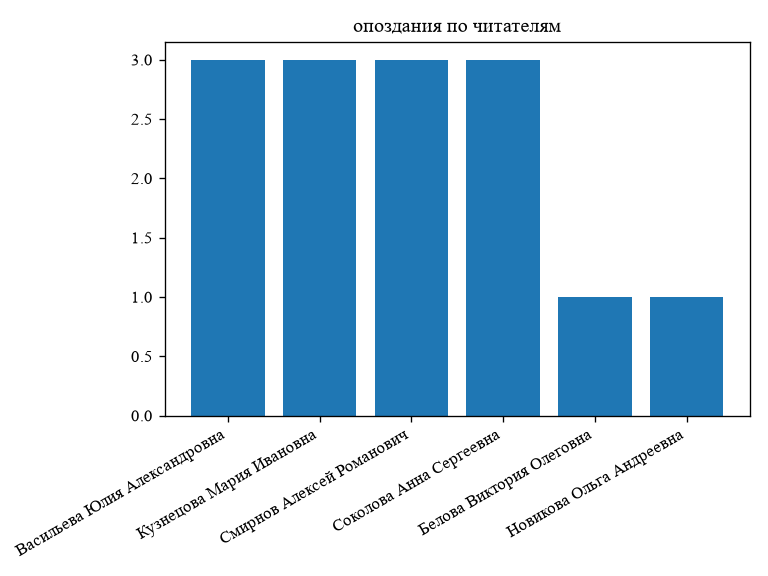

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ch = pd.read_csv('chitatel.csv')
v = pd.read_csv('vydacha.csv')
k = pd.read_csv('kniga.csv')
t = ch.merge(v, on='chitatel_id').merge(k, on='kniga_id')
t = t[t['vozrast'] >= 18]
t['data_vozvrata'] = pd.to_datetime(t['data_vozvrata'])
t['srok_sdachi'] = pd.to_datetime(t['srok_sdachi'])
t['prosrochka'] = np.where(t['data_vozvrata'] > t['srok_sdachi'], 1, 0)
t.loc[t['data_vozvrata'].isna() & (t['srok_sdachi'] < pd.Timestamp('2026-08-29')), 'prosrochka'] = 1
g = t.groupby(['chitatel_id', 'fio'], as_index=False).agg(skok_bral=('vydacha_id', 'count'), opozdal=('prosrochka', 'sum'))
g['risk'] = np.where(g['opozdal'] >= 2, 1, 0)
g['mesto'] = g['opozdal'].rank(ascending=False, method='min').astype(int)
g = g.sort_values(['opozdal', 'fio'], ascending=[False, True])
print(g.to_string(index=False))

late = g[g['opozdal'] > 0]
plt.bar(late['fio'], late['opozdal'])
plt.xticks(rotation=30, ha='right')
plt.title('опоздания по читателям')
plt.tight_layout()
plt.savefig('dz08_bar.png', dpi=120)
